# EEG Rhythms & Complexity

This notebook explores EEG rhythmic activity and signal complexity during deep sleep and wakefulness.

Goals:
- Visualize canonical EEG frequency bands
- Estimate spectral slope (1/f dynamics)
- Compute Lempel-Ziv complexity
- Compare signatures of reduced consciousness

In [1]:
import mne
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import linregress
import antropy as ant

## EEG Data

Load resting-state and sleep EEG from the same participant.

In [38]:
wake_raw = mne.io.read_raw_brainvision(
    "../data/raw/sleep_data/sub_23/eeg/sub-23_task-rest_run-1_eeg.vhdr",
    preload=True
)


wake_raw.set_channel_types({
    ch: "eeg"
    for ch in wake_raw.ch_names
    if ch not in ["EOG", "ECG"]
})


wake_filtered = wake_raw.copy().filter(
    0.5,
    45,
    picks="eeg"
)

Extracting parameters from ../data/raw/sleep_data/sub_23/eeg/sub-23_task-rest_run-1_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 3307399  =      0.000 ...   661.480 secs...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17496\2242507534.py:1: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  wake_raw = mne.io.read_raw_brainvision(
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17496\2242507534.py:7: RuntimeWarning: The unit for channel(s) C3, C4, CP1, CP2, CP5, CP6, Cz, F3, F4, F7, F8, FC1, FC2, FC5, FC6, Fp1, Fp2, Fz, O1, O2, Oz, P3, P4, P7, P8, Pz, T7, T8, TP10, TP9 has changed from NA to V.
  wake_raw.set_channel_types({


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 33001 samples (6.600 s)



In [2]:
raw = mne.io.read_raw_brainvision(
    "C:\\Users\\Lenovo\\Desktop\\data_prjcts\\different-paths-to-unresponsiveness\\data\\raw\\sleep_data\\sub_23\\eeg\\sub-23_task-sleep_run-3_eeg.vhdr",
    preload=True
)

Extracting parameters from C:\Users\Lenovo\Desktop\data_prjcts\different-paths-to-unresponsiveness\data\raw\sleep_data\sub_23\eeg\sub-23_task-sleep_run-3_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 4601199  =      0.000 ...   920.240 secs...


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17496\2673189468.py:1: RuntimeWarning: Channels contain different highpass filters. Lowest (weakest) filter setting (0.00 Hz) will be stored.
  raw = mne.io.read_raw_brainvision(


In [4]:
channel_types = {
    ch: "eeg" for ch in raw.ch_names
}

channel_types["EOG"] = "eog"
channel_types["ECG"] = "ecg"

raw.set_channel_types(channel_types)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_17496\3843225156.py:8: RuntimeWarning: The unit for channel(s) C3, C4, CP1, CP2, CP5, CP6, Cz, ECG, EOG, F3, F4, F7, F8, FC1, FC2, FC5, FC6, Fp1, Fp2, Fz, O1, O2, Oz, P3, P4, P7, P8, Pz, T7, T8, TP10, TP9 has changed from NA to V.
  raw.set_channel_types(channel_types)


<RawBrainVision | sub-23_task-sleep_run-3_eeg.eeg, 32 x 4601200 (920.2 s), ~1.10 GiB, data loaded>

In [5]:
eeg_channels = mne.pick_types(
    raw.info,
    eeg=True
)

filtered = raw.copy().filter(
    0.5,
    45,
    picks=eeg_channels
)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 33001 samples (6.600 s)



## Delta Rhythm (0.5–4 Hz) during sleep

Delta activity dominates deep NREM sleep and reflects highly synchronized cortical dynamics.

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 33001 samples (6.600 s)

Using matplotlib as 2D backend.


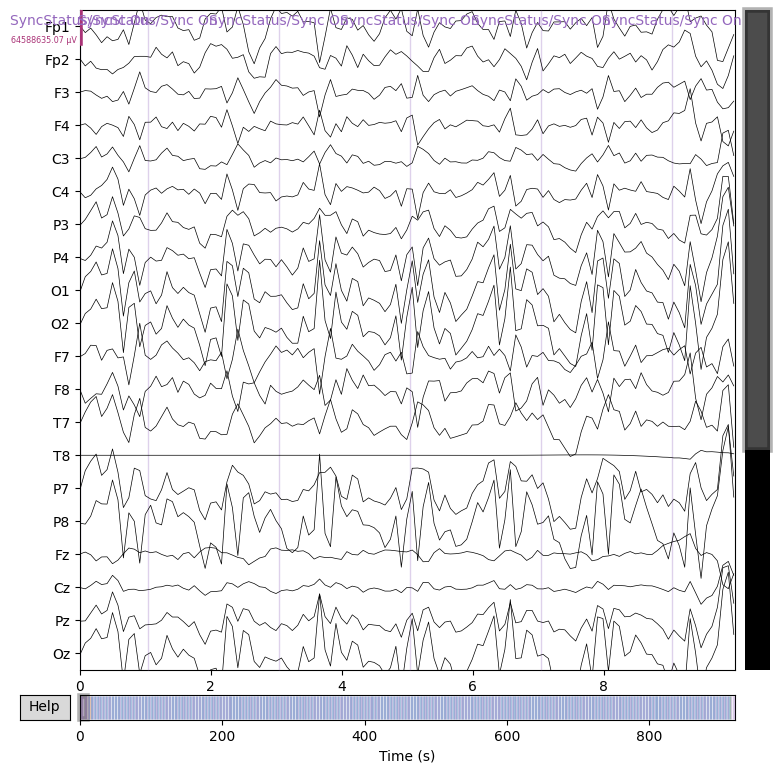

In [6]:
delta = filtered.copy().filter(
    0.5,
    4,
    picks=eeg_channels
)

delta.plot(
    duration=10,
    picks=eeg_channels,
    scalings='auto'
)

plt.show()

## Delta Rhythm (0.5–4 Hz) during wakefulness

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 4 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 4.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 5.00 Hz)
- Filter length: 33001 samples (6.600 s)



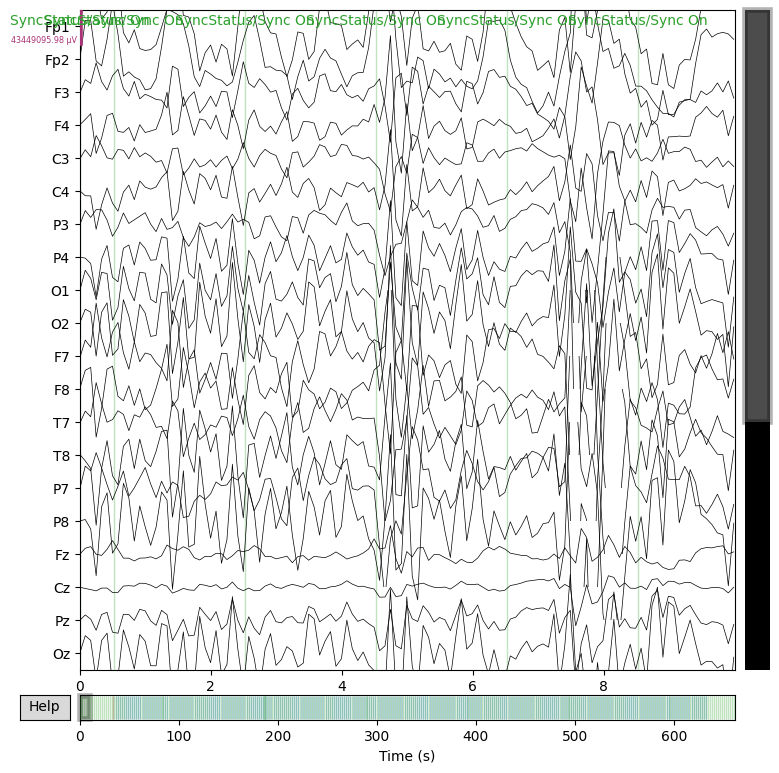

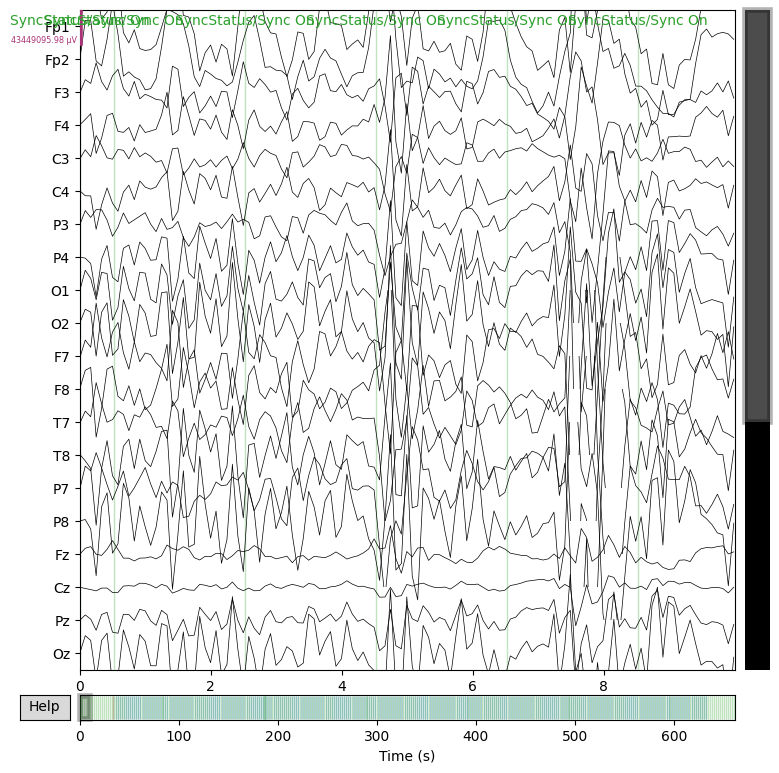

In [34]:
wake_delta = wake_filtered.copy().filter(
    0.5,
    4,
    picks="eeg"
)

wake_delta.plot(
    duration=10,
    scalings="auto"
)

## Alpha Rhythm (8–12 Hz) during sleep

Alpha oscillations are associated with relaxed wakefulness and tend to diminish during deep unconscious states.

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 8251 samples (1.650 s)



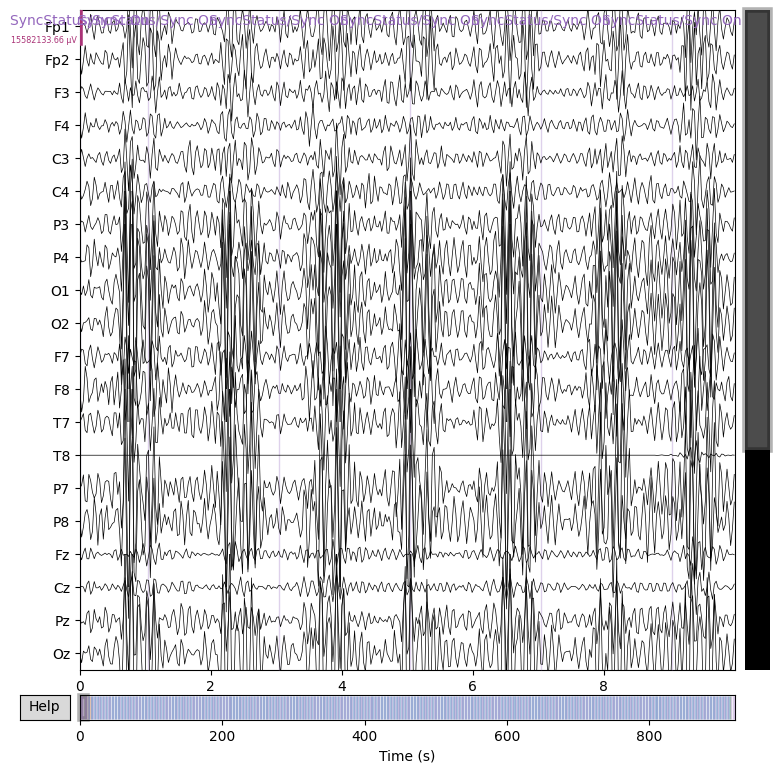

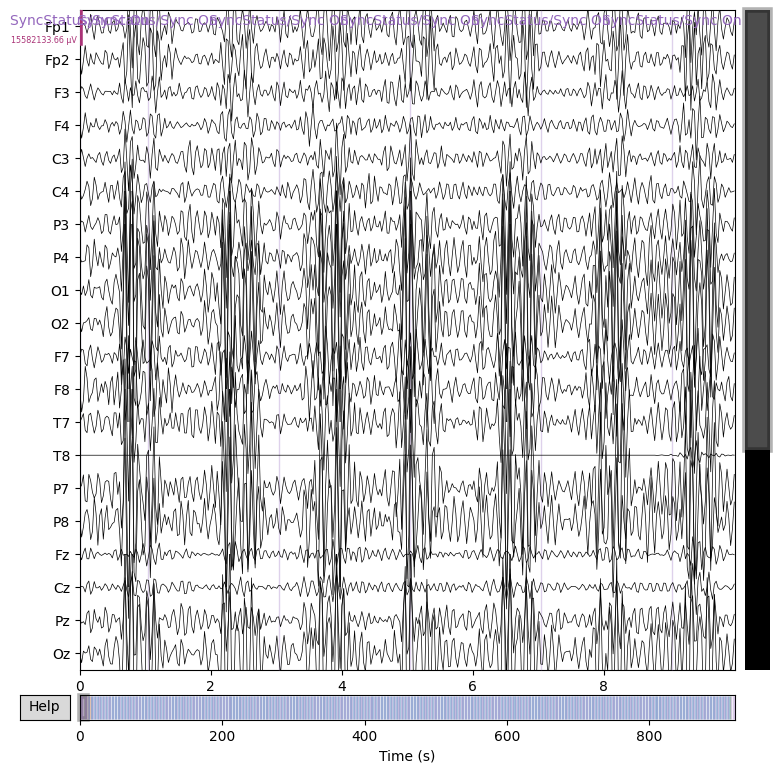

In [7]:
alpha = filtered.copy().filter(8, 12)

alpha.plot(
    duration=10,
    picks=eeg_channels,
    scalings='auto'
)

## Alpha Rhythm (8–12 Hz) during wakefulness

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 8 - 12 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 8.00
- Lower transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 7.00 Hz)
- Upper passband edge: 12.00 Hz
- Upper transition bandwidth: 3.00 Hz (-6 dB cutoff frequency: 13.50 Hz)
- Filter length: 8251 samples (1.650 s)



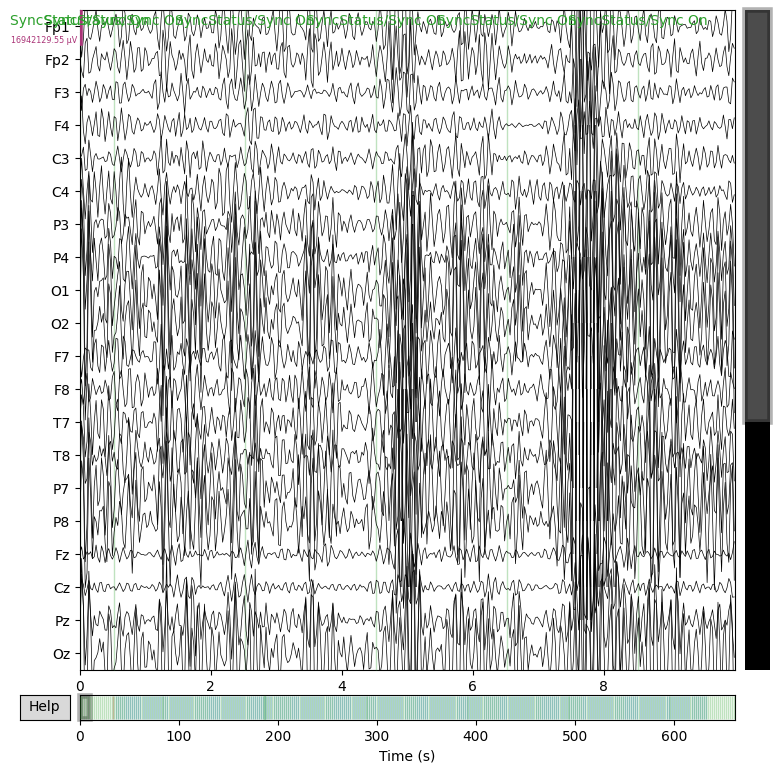

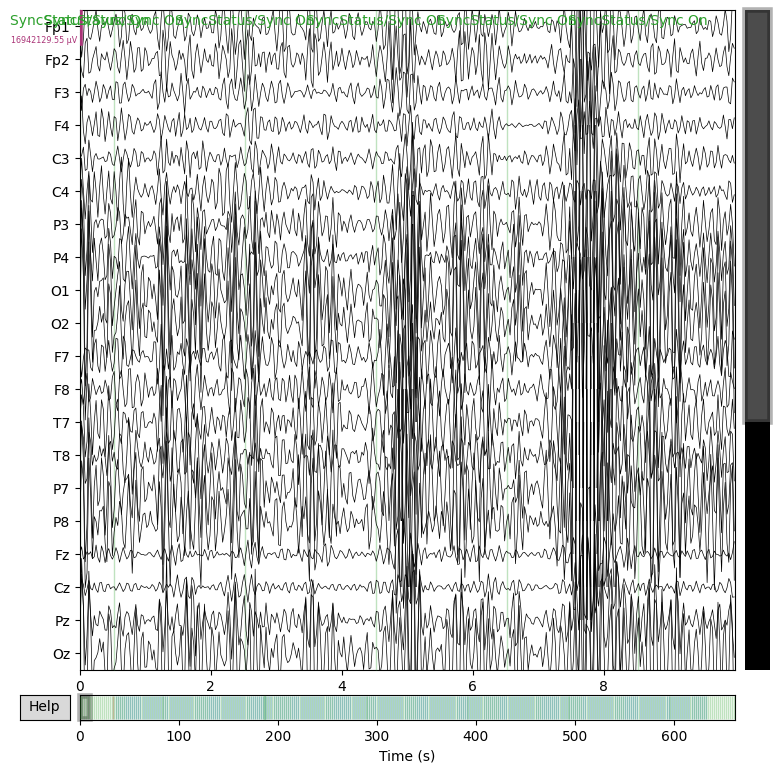

In [36]:
wake_alpha = wake_filtered.copy().filter(
    8,
    12,
    picks="eeg"
)

wake_alpha.plot(
    duration=10,
    scalings="auto"
)

## Beta Rhythm (13–30 Hz) during sleep

Beta activity reflects faster cortical processing and cognitive engagement.

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 5077 samples (1.015 s)



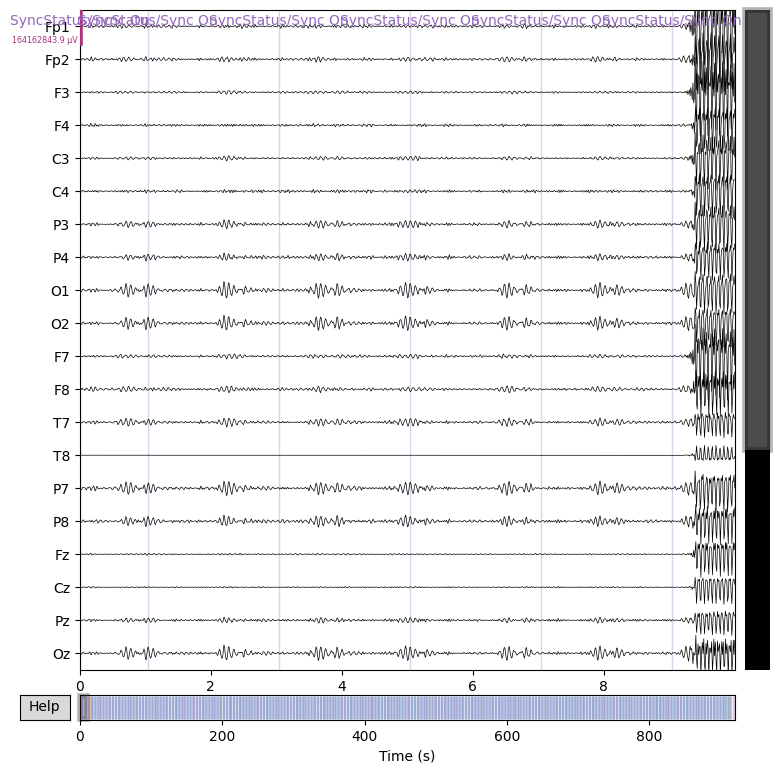

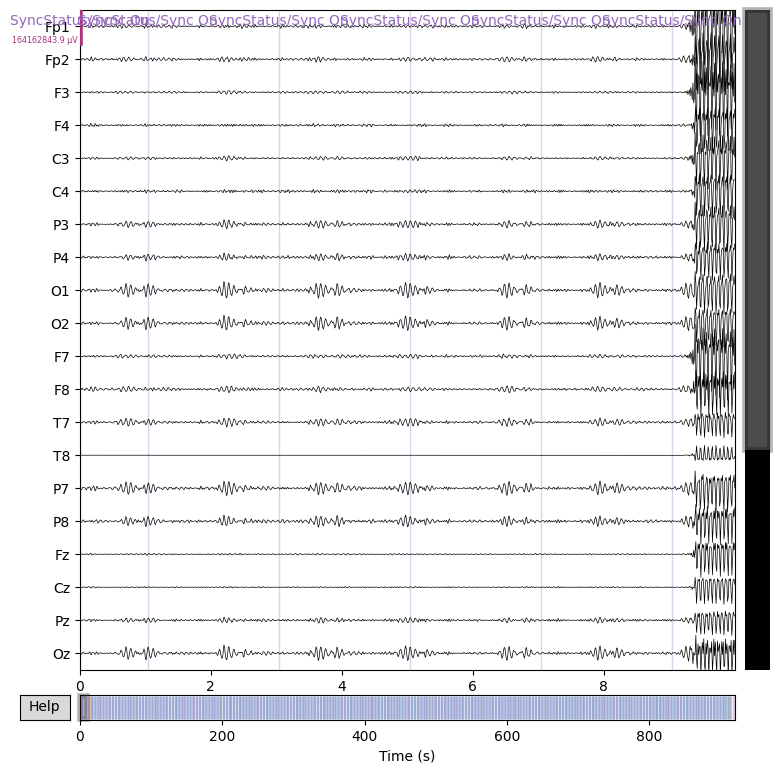

In [8]:
beta = filtered.copy().filter(13, 30)

beta.plot(
    duration=10,
    picks=eeg_channels,
    scalings='auto'
)

## Beta Rhythm (13–30 Hz) during wakefulness

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 13 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 13.00
- Lower transition bandwidth: 3.25 Hz (-6 dB cutoff frequency: 11.38 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 5077 samples (1.015 s)



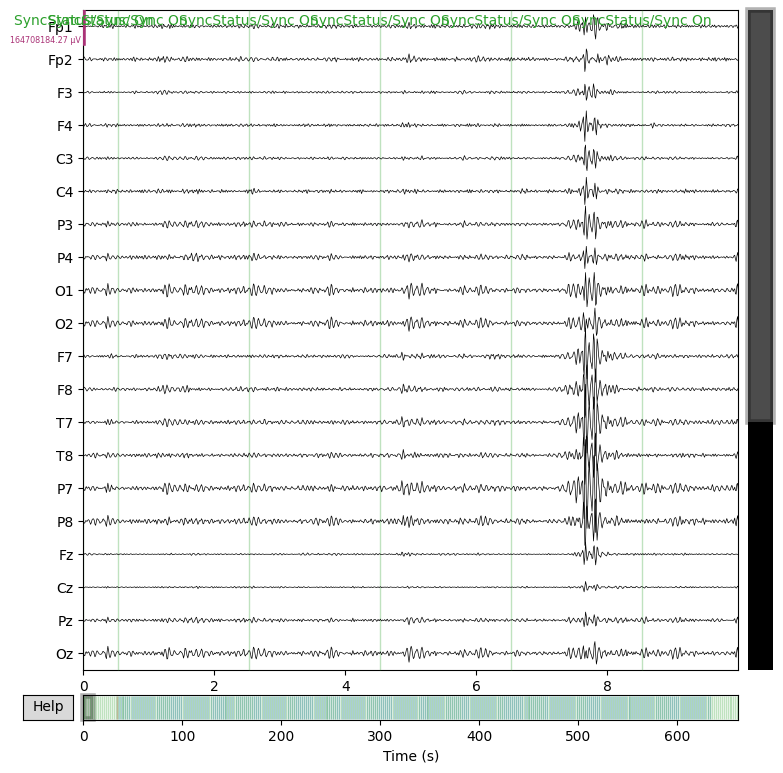

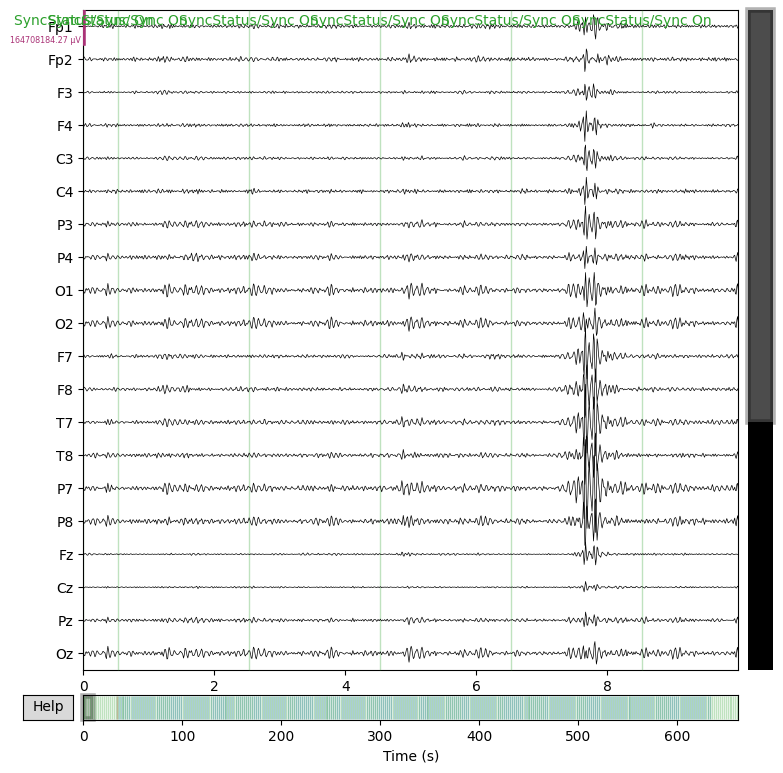

In [35]:
wake_beta = wake_filtered.copy().filter(
    13,
    30,
    picks="eeg"
)

wake_beta.plot(
    duration=10,
    scalings="auto"
)

## Interpretation of EEG Rhythms

EEG rhythms reflect different modes of large-scale neuronal activity.

### Delta Band (0.5–4 Hz)

Delta oscillations are the dominant feature of deep non-REM sleep. They represent highly synchronized cortical activity and are associated with reduced responsiveness and diminished conscious awareness.

### Alpha Band (8–12 Hz)

Alpha activity is typically observed during relaxed wakefulness, especially with closed eyes. It is often strongest over occipital regions and tends to decrease during active cognitive processing.

### Beta Band (13–30 Hz)

Beta oscillations are linked to alertness, sensory processing, and cognitive engagement. Higher beta activity is generally associated with wakefulness and conscious information processing.

### Observations

Visual inspection suggests differences in rhythmic structure between wakefulness and sleep. Sleep recordings show stronger low-frequency oscillations, whereas wakefulness exhibits relatively greater high-frequency activity.

These observations are consistent with the transition from a more information-rich conscious state toward the highly synchronized dynamics characteristic of deep sleep.

# Spectral Slope (1/f Dynamics)

Beyond individual frequency bands, neural activity can be characterized by the overall shape of the power spectrum.

A common observation in electrophysiology is that power decreases with frequency according to an approximate 1/f relationship. Changes in the spectral slope have been linked to arousal, excitation-inhibition balance, and levels of consciousness.

In this section, we estimate the spectral slope of the EEG power spectrum and compare wakefulness with sleep.

In [9]:
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.stats import linregress

### Sleep spectral slope

In [10]:
data = filtered.get_data(picks=eeg_channels)

sfreq = filtered.info["sfreq"]

freqs, psd = welch(
    data,
    fs=sfreq,
    nperseg=2048
)

mean_psd = psd.mean(axis=0)

In [46]:
psd = filtered.compute_psd(
    fmin=1,
    fmax=45
)

psd_data = psd.get_data().mean(axis=0)
freqs = psd.freqs

mask = (
    (freqs >= 1)
    & (freqs <= 40)
)

freqs_fit = freqs[mask]
psd_fit = psd_data[mask]


log_freqs = np.log10(freqs_fit)
log_psd = np.log10(psd_fit)

slope, intercept = np.polyfit(
    log_freqs,
    log_psd,
    1
)

print("Sleep spectral slope:", slope)

Effective window size : 0.410 (s)
Sleep spectral slope: -0.05617601020825473


### Wakefulness spectral slope

In [42]:
wake_data = wake_filtered.get_data(
    picks="eeg"
)

wake_sfreq = wake_filtered.info["sfreq"]

wake_freqs_welch, wake_psd_welch = welch(
    wake_data,
    fs=wake_sfreq,
    nperseg=2048
)

wake_mean_psd = wake_psd_welch.mean(axis=0)



wake_psd = wake_filtered.compute_psd(
    fmin=1,
    fmax=45
)

wake_psd_data = wake_psd.get_data().mean(axis=0)
wake_freqs = wake_psd.freqs



wake_mask = (
    (wake_freqs >= 1)
    & (wake_freqs <= 40)
)

wake_freqs_fit = wake_freqs[wake_mask]
wake_psd_fit = wake_psd_data[wake_mask]



wake_log_freqs = np.log10(
    wake_freqs_fit
)

wake_log_psd = np.log10(
    wake_psd_fit
)



wake_slope, wake_intercept = np.polyfit(
    wake_log_freqs,
    wake_log_psd,
    1
)

print(
    "Wake spectral slope:",
    wake_slope
)

Effective window size : 0.410 (s)
Wake spectral slope: -0.04114743259816495


## Interpretation

The spectral slope was estimated in the 30–45 Hz range.

More negative values indicate a steeper decay of high-frequency activity,
which is commonly associated with reduced cortical complexity and lower levels
of consciousness.

In this example:

- Wake: -0.041
- Sleep: -0.056

The sleep recording showed a slightly steeper spectral slope.

## Lempel-Ziv Complexity

In [53]:
eeg_channels = mne.pick_types(
    filtered.info,
    eeg=True
)

lzc_values = []

for ch in eeg_channels:
    signal = filtered_resampled.get_data(
        picks=[ch]
    )[0]

    signal = signal[:int(sfreq * 30)]

    signal = (
        signal - np.mean(signal)
    ) / np.std(signal)

    binary = signal > np.median(signal)

    lzc = ant.lziv_complexity(
        binary,
        normalize=True
    )

    lzc_values.append(lzc)

sleep_lzc_mean = np.mean(lzc_values)
sleep_lzc_std = np.std(lzc_values)

print("Mean Sleep LZC:", sleep_lzc_mean)
print("Std Sleep LZC:", sleep_lzc_std)

Mean Sleep LZC: 0.37325035963949077
Std Sleep LZC: 0.09117363787231599


In [51]:
filtered_wake_resampled = wake_filtered.copy().resample(250)

wake_sfreq = filtered_wake_resampled.info["sfreq"]

wake_eeg_channels = mne.pick_types(
    filtered_wake_resampled.info,
    eeg=True
)

wake_lzc_values = []

for ch in wake_eeg_channels:

    signal = filtered_wake_resampled.get_data(
        picks=[ch]
    )[0]

    segment = signal[
        0:int(wake_sfreq * 30)
    ]

    segment = (
        segment - np.mean(segment)
    ) / np.std(segment)

    binary_signal = (
        segment > np.median(segment)
    )

    lzc = ant.lziv_complexity(
        binary_signal,
        normalize=True
    )

    wake_lzc_values.append(lzc)

wake_lzc_mean = np.mean(wake_lzc_values)
wake_lzc_std = np.std(wake_lzc_values)

print("Mean Wake LZC:", wake_lzc_mean)
print("Std Wake LZC:", wake_lzc_std)

Mean Wake LZC: 0.35105214695706866
Std Wake LZC: 0.06487091507387786


Lempel-Ziv Complexity was estimated across all EEG channels and averaged.

Results:

| State | Mean LZC |
|---------|---------:|
| Wake | 0.351 |
| Sleep | 0.373 |

Contrary to the expected decrease in complexity during unconscious states, the selected sleep segment showed slightly higher complexity.

Possible explanations include:

- limited recording duration,
- channel variability,
- sleep-stage heterogeneity,
- absence of artifact correction.

This result highlights the importance of multi-epoch and multi-subject analyses when using complexity metrics as biomarkers of consciousness.

# Conclusions

This notebook explored multiple EEG-based signatures of consciousness and reduced responsiveness.

### Key Findings

#### EEG Rhythms

Visual inspection of canonical EEG frequency bands revealed clear oscillatory structure across both wakefulness and sleep. Slow-wave activity (delta band) was particularly prominent during sleep, reflecting increased neuronal synchrony.

#### Spectral Slope

The EEG power spectrum exhibited an approximately 1/f structure in both conditions. Spectral slope estimates were slightly steeper during sleep, suggesting a shift toward slower and more synchronized neural dynamics.

#### Lempel-Ziv Complexity

Lempel-Ziv Complexity was used as a measure of signal diversity and information richness.

Although complexity was expected to decrease during unconsciousness, the selected sleep segment showed slightly higher complexity. This may reflect channel variability, sleep-stage heterogeneity, or limitations of single-subject analysis.

### Limitations

- Single participant
- Single wake and sleep recording
- Short analysis windows
- No sleep-stage verification
- No artifact rejection via ICA

### Future Work

Potential extensions include:

- Multi-epoch complexity estimation
- Nonlinear dynamics analysis
- Phase-space reconstruction
- Chaotic attractor visualization
- Comparison with propofol-induced unconsciousness using fMRI

Overall, the analysis demonstrates how spectral and complexity-based EEG metrics can be used to characterize different states of consciousness.